# Análisis de resultados — Péndulo Amortiguado (Problema Inverso)

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN
aplicada al péndulo amortiguado como problema inverso. La PINN aprende
simultáneamente la trayectoria y los parámetros físicos g y μ a partir de
datos ruidosos. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 50, 100, 500, 1000, 2000 (base)
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam+L-BFGS (base) vs. Adam
4. **Arquitectura**: [32,32,32,32,32] (base) vs. [64,64,64,64,64]
5. **Pesos dinámicos**: desactivados (base) vs. activados
6. **Learning rate**: 0.001 (base) vs. 0.01
7. **Ruido**: 0.0, 0.05 (base), 0.1, 0.2
8. **Puntos de entrenamiento**: 5, 10, 15 (base), 30
9. **Región de entrenamiento**: 30%, 50% (base), 70%
10. **Cruce puntos × región 70%**: combinaciones

Cada configuración se ejecuta con 10 seeds distintas.
La referencia numérica es RK4 (ground truth).
A diferencia de los sistemas anteriores, el objetivo principal no es
solo minimizar el error L2, sino recuperar con precisión los parámetros
físicos g y μ a partir de observaciones ruidosas.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_pendulo")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_RK4  = "#888888"

G_TRUE  = 9.81
MU_TRUE = 0.5

In [2]:
records_pendulo = []

for fpath in sorted(RESULTS_DIR.glob("pendulo_inverso/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_pendulo.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "noise_std":           cfg["noise_std"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "g_learned":           res["pinn"]["g_learned"],
        "mu_learned":          res["pinn"]["mu_learned"],
        "error_rel_g":         res["pinn"]["error_relativo_g"],
        "error_rel_mu":        res["pinn"]["error_relativo_mu"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados RK4 ─────────────────────────────────────────
        "time_rk4":            res["rk4"]["time_s"],
    })

df_pendulo = pd.DataFrame(records_pendulo)
print(f"Total experimentos cargados: {len(df_pendulo)}")
df_pendulo.head()

Total experimentos cargados: 210


,seed,epochs,lr,num_domain_points,num_train_points,train_region,noise_std,sampler,use_dynamic_weights,optimizer,hidden_layers,error_l2_pinn,time_pinn,g_learned,mu_learned,error_rel_g,error_rel_mu,error_l2_nn,time_nn,time_rk4
0,42,10000,0.001,2000,15,0.5,0.05,grid,False,adam+lbfgs,"[32, 32, 32, 32, 32]",0.068207,405.330217,9.734406,0.508691,0.007706,0.017381,0.951535,19.545006,0.007999
1,123,10000,0.001,2000,15,0.5,0.05,grid,False,adam+lbfgs,"[32, 32, 32, 32, 32]",0.222435,401.155457,9.787776,0.674670,0.002265,0.349339,1.884912,166.447416,0.006000
2,7,10000,0.001,2000,15,0.5,0.05,grid,False,adam+lbfgs,"[32, 32, 32, 32, 32]",NaN,673.396638,NaN,NaN,NaN,NaN,0.632192,16.375372,0.006998
3,99,10000,0.001,2000,15,0.5,0.05,grid,False,adam+lbfgs,"[32, 32, 32, 32, 32]",0.294705,591.403900,9.572349,0.770678,0.024225,0.541355,51.277927,53.112841,0.006999
4,2024,10000,0.001,2000,15,0.5,0.05,grid,False,adam+lbfgs,"[32, 32, 32, 32, 32]",0.388211,599.875166,9.052048,0.949787,0.077263,0.899574,0.649689,35.170758,0.006001


In [3]:
BASE_PENDULO = {
    "num_domain_points":   2000,
    "num_train_points":    15,
    "train_region":        0.5,
    "noise_std":           0.05,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "optimizer":           "adam+lbfgs",
    "hidden_layers":       "[32, 32, 32, 32, 32]",
    "lr":                  0.001,
}

def is_base_pendulo(row):
    return all(row[k] == v for k, v in BASE_PENDULO.items())

df_pendulo["is_base"] = df_pendulo.apply(is_base_pendulo, axis=1)
df_base_pendulo = df_pendulo[df_pendulo["is_base"]]

print(f"Experimentos BASE: {len(df_base_pendulo)} (esperados: 10)")
print(f"\nError L2 PINN — media: {df_base_pendulo['error_l2_pinn'].mean():.4e} "
      f"± {df_base_pendulo['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   — media: {df_base_pendulo['error_l2_nn'].mean():.4e} "
      f"± {df_base_pendulo['error_l2_nn'].std():.4e}")
print(f"\ng verdadero:  {G_TRUE}")
print(f"g aprendido  — media: {df_base_pendulo['g_learned'].mean():.4f} "
      f"± {df_base_pendulo['g_learned'].std():.4f} "
      f"| error rel.: {df_base_pendulo['error_rel_g'].mean()*100:.2f}%")
print(f"\nmu verdadero: {MU_TRUE}")
print(f"mu aprendido — media: {df_base_pendulo['mu_learned'].mean():.4f} "
      f"± {df_base_pendulo['mu_learned'].std():.4f} "
      f"| error rel.: {df_base_pendulo['error_rel_mu'].mean()*100:.2f}%")
print(f"\nTiempo PINN — media: {df_base_pendulo['time_pinn'].mean():.2f}s "
      f"± {df_base_pendulo['time_pinn'].std():.2f}s")
print(f"Tiempo NN   — media: {df_base_pendulo['time_nn'].mean():.2f}s "
      f"± {df_base_pendulo['time_nn'].std():.2f}s")
print(f"Tiempo RK4  — media: {df_base_pendulo['time_rk4'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN — media: 1.3603e-01 ± 5.3664e-02
Error L2 NN   — media: 6.4777e+00 ± 1.5902e+01

g verdadero:  9.81
g aprendido  — media: 9.7462 ± 0.0738 | error rel.: 0.72%

mu verdadero: 0.5
mu aprendido — media: 0.5924 ± 0.0659 | error rel.: 18.49%

Tiempo PINN — media: 405.68s ± 94.40s
Tiempo NN   — media: 42.15s ± 47.45s
Tiempo RK4  — media: 0.0058s


## Eje 1 — Puntos de colocación

Se varía el número de puntos de colocación entre 50 y 2000. La NN pura no
depende de este parámetro y se representa como referencia horizontal.
Además del error L2, se analiza el efecto sobre la recuperación de g y μ.

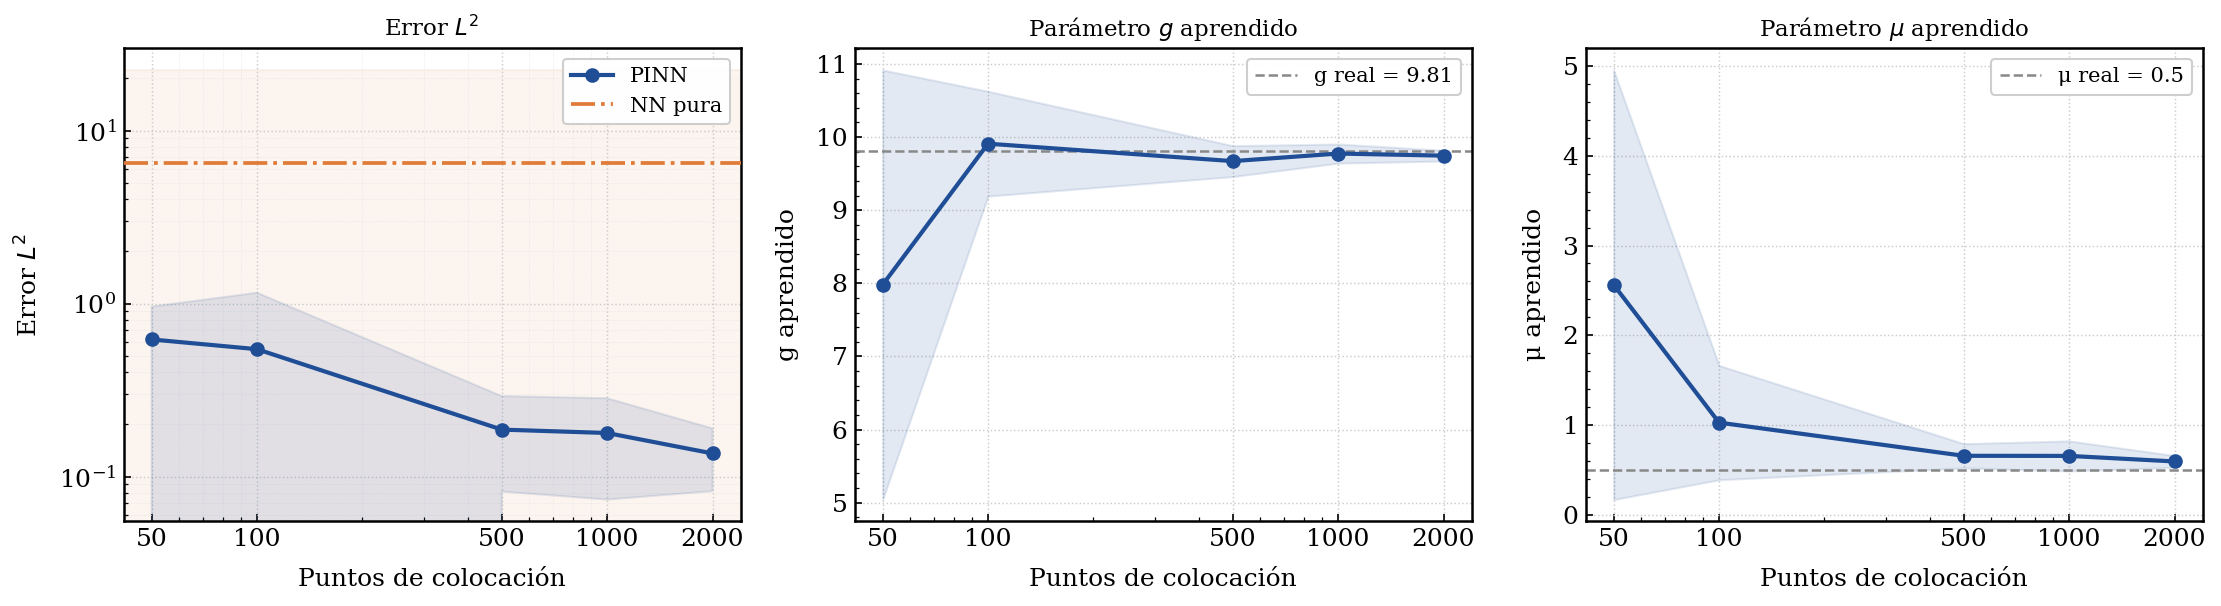

NN pura: 6.4777e+00 ± 1.5902e+01

   pts      PINN L2    g media    g std   mu media   mu std   err g%  err mu%
    50   6.1990e-01     7.9805   2.9372     2.5626   2.3952    26.76   444.68
   100   5.4465e-01     9.9097   0.7166     1.0256   0.6374     4.59   105.12
   500   1.8677e-01     9.6714   0.2115     0.6554   0.1355     1.81    31.07
  1000   1.7853e-01     9.7748   0.1307     0.6542   0.1672     1.12    30.84
  2000   1.3603e-01     9.7462   0.0738     0.5924   0.0659     0.72    18.49


In [4]:
configs_eje1 = [50, 100, 500, 1000, 2000]

mask_eje1_pendulo = (
    df_pendulo["num_domain_points"].isin(configs_eje1) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje1_pendulo = df_pendulo[mask_eje1_pendulo].groupby("num_domain_points").agg(
    pinn_mean    =("error_l2_pinn", "mean"),
    pinn_std     =("error_l2_pinn", "std"),
    g_mean       =("g_learned",     "mean"),
    g_std        =("g_learned",     "std"),
    mu_mean      =("mu_learned",    "mean"),
    mu_std       =("mu_learned",    "std"),
    err_g_mean   =("error_rel_g",   "mean"),
    err_mu_mean  =("error_rel_mu",  "mean"),
).reset_index()

x    = df_eje1_pendulo["num_domain_points"].values
y_p  = df_eje1_pendulo["pinn_mean"].values
s_p  = df_eje1_pendulo["pinn_std"].values
y_nn = df_base_pendulo["error_l2_nn"].mean()
s_nn = df_base_pendulo["error_l2_nn"].std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(y_nn, color=C_NN, linewidth=1.8, linestyle="-.",
           zorder=3, label="NN pura")
ax.axhspan(y_nn - s_nn, y_nn + s_nn,
           color=C_NN, alpha=0.08, zorder=1)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje1_pendulo["g_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje1_pendulo["g_mean"] - df_eje1_pendulo["g_std"],
    df_eje1_pendulo["g_mean"] + df_eje1_pendulo["g_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_xscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
ax.plot(x, df_eje1_pendulo["mu_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje1_pendulo["mu_mean"] - df_eje1_pendulo["mu_std"],
    df_eje1_pendulo["mu_mean"] + df_eje1_pendulo["mu_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.set_xlabel("Puntos de colocación", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_xscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura: {y_nn:.4e} ± {s_nn:.4e}")
print(f"\n{'pts':>6} {'PINN L2':>12} {'g media':>10} {'g std':>8} "
      f"{'mu media':>10} {'mu std':>8} {'err g%':>8} {'err mu%':>8}")
for _, row in df_eje1_pendulo.iterrows():
    print(f"{int(row['num_domain_points']):>6} {row['pinn_mean']:>12.4e} "
          f"{row['g_mean']:>10.4f} {row['g_std']:>8.4f} "
          f"{row['mu_mean']:>10.4f} {row['mu_std']:>8.4f} "
          f"{row['err_g_mean']*100:>8.2f} {row['err_mu_mean']*100:>8.2f}")

## Eje 2 — Sampler

Se compara LHS frente a malla uniforme. El sampler no afecta a la NN pura,
que se representa como referencia horizontal. Para el problema inverso,
además del error L2 se analiza el efecto sobre la recuperación de g y μ.

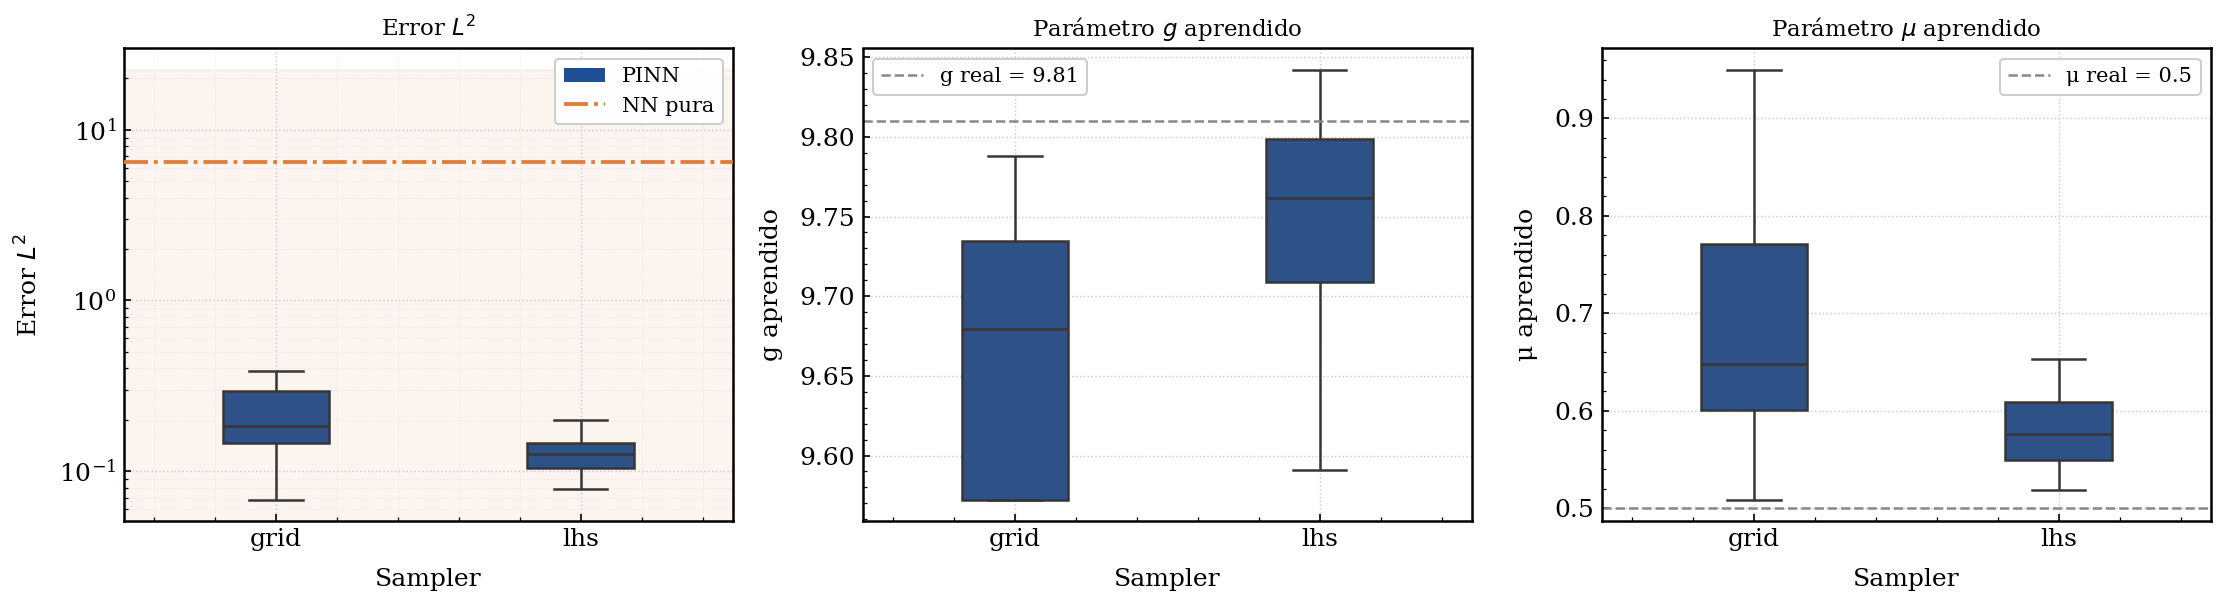

grid: L2=2.1343e-01 ± 1.1195e-01 | g=9.5667 ± 0.2739 | mu=0.6856 ± 0.1510
lhs: L2=1.3603e-01 ± 5.3664e-02 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
NN pura: 6.4777e+00 ± 1.5902e+01


In [5]:
mask_eje2_pendulo = (
    df_pendulo["sampler"].isin(["lhs", "grid"]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje2_pendulo = df_pendulo[mask_eje2_pendulo].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje2_pendulo, x="sampler", y="error_l2_pinn",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_pendulo["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
ax.axhspan(
    df_base_pendulo["error_l2_nn"].mean() - df_base_pendulo["error_l2_nn"].std(),
    df_base_pendulo["error_l2_nn"].mean() + df_base_pendulo["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1
)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_eje2_pendulo, x="sampler", y="g_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
sns.boxplot(
    data=df_eje2_pendulo, x="sampler", y="mu_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df_pendulo[mask_eje2_pendulo].groupby("sampler"):
    print(f"{sampler}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")
print(f"NN pura: {df_base_pendulo['error_l2_nn'].mean():.4e} ± {df_base_pendulo['error_l2_nn'].std():.4e}")

## Eje 3 — Optimizador

Se compara Adam+L-BFGS (BASE) frente a Adam puro. El optimizador afecta tanto
a la PINN como a la NN, por lo que se incluyen ambas en la comparación del
error L2. Para g y μ solo tiene sentido mostrar la PINN.

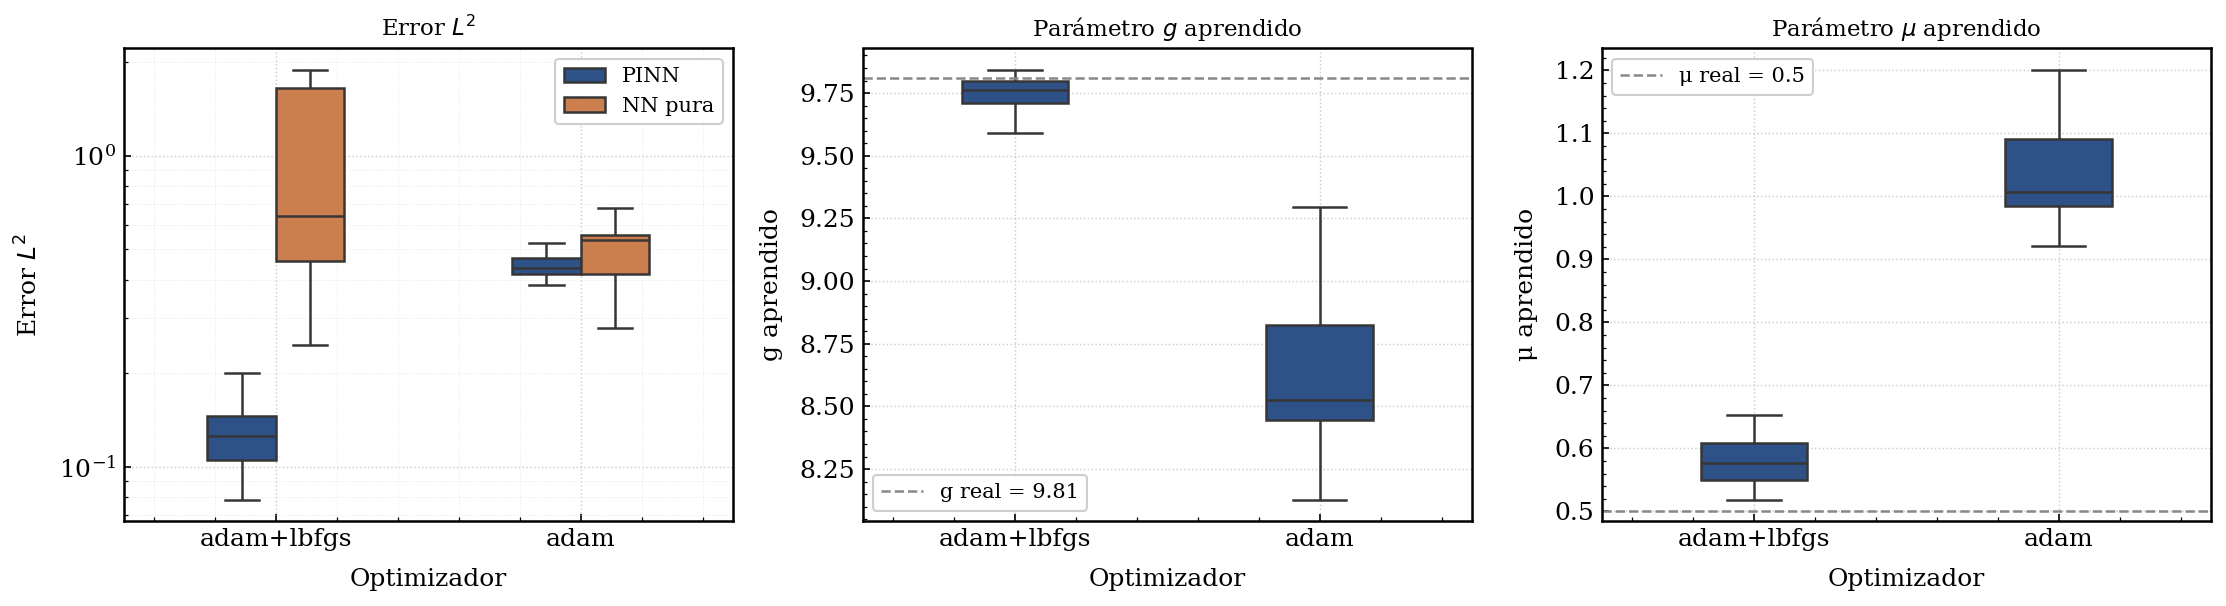

adam: L2=4.3028e-01 ± 7.3252e-02 | NN=5.2464e-01 ± 1.7813e-01 | g=8.6491 ± 0.3738 | mu=1.0119 ± 0.1365
adam+lbfgs: L2=1.3603e-01 ± 5.3664e-02 | NN=6.4777e+00 ± 1.5902e+01 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659


In [6]:
mask_eje3_pendulo = (
    df_pendulo["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje3_long = df_pendulo[mask_eje3_pendulo].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje3_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_pendulo[mask_eje3_pendulo], x="optimizer", y="g_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
sns.boxplot(
    data=df_pendulo[mask_eje3_pendulo], x="optimizer", y="mu_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df_pendulo[mask_eje3_pendulo].groupby("optimizer"):
    print(f"{opt}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")

## Eje 4 — Arquitectura

Se compara la arquitectura base [32,32,32,32,32] frente a [64,64,64,64,64].
El aumento de capacidad afecta tanto a la PINN como a la NN, por lo que
se incluyen ambas en el panel de error L2.

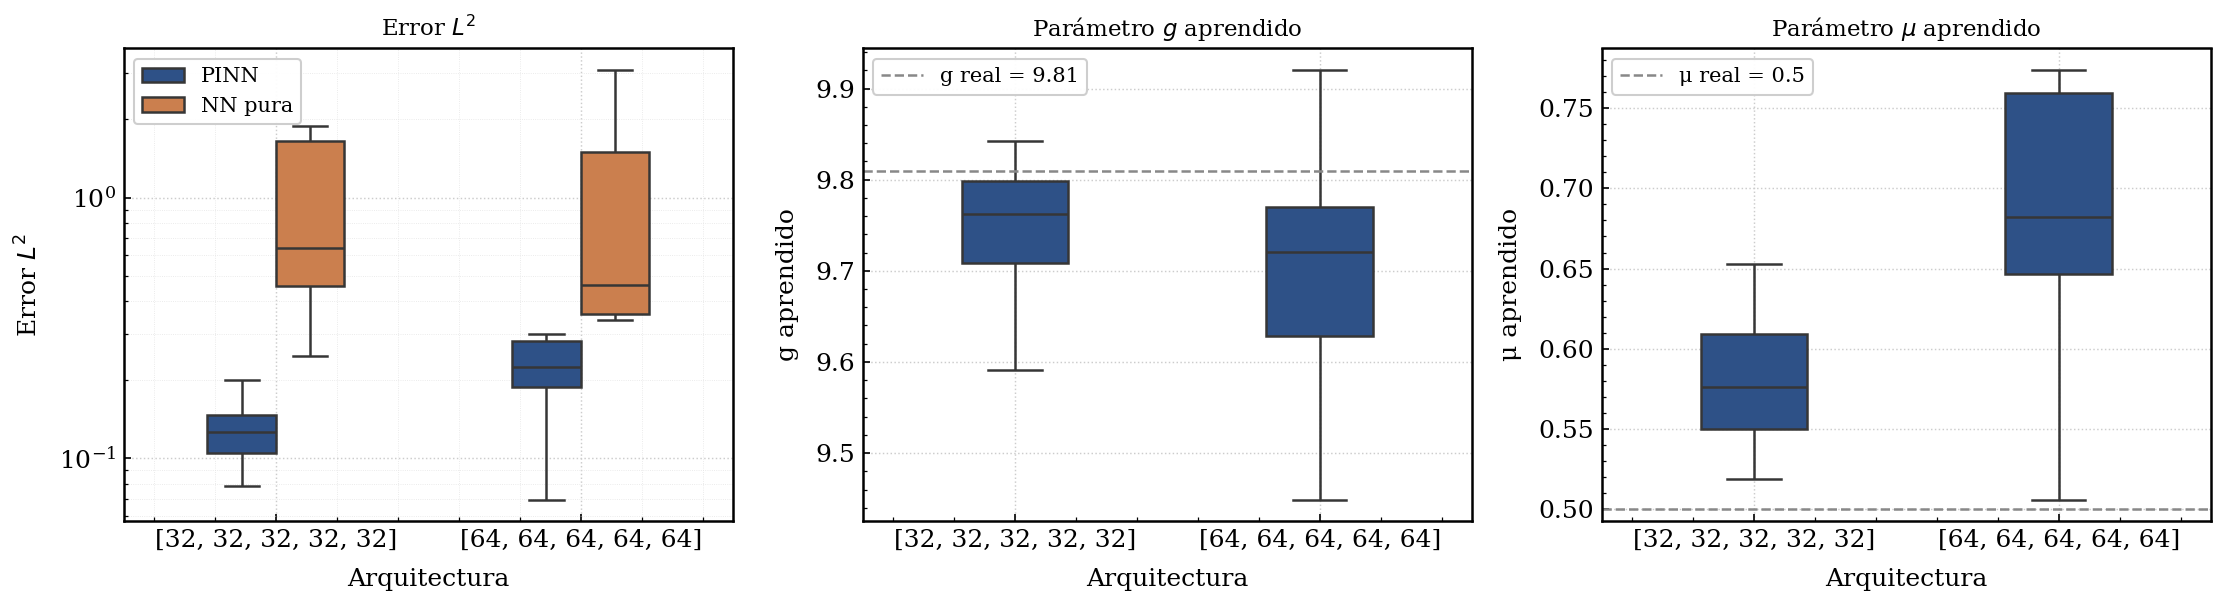

[32, 32, 32, 32, 32]: L2=1.3603e-01 ± 5.3664e-02 | NN=6.4777e+00 ± 1.5902e+01 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
[64, 64, 64, 64, 64]: L2=2.1797e-01 ± 7.3837e-02 | NN=1.1674e+00 ± 1.2580e+00 | g=9.6658 ± 0.2019 | mu=0.6810 ± 0.0861


In [7]:
mask_eje4_pendulo = (
    df_pendulo["hidden_layers"].isin(["[32, 32, 32, 32, 32]", "[64, 64, 64, 64, 64]"]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje4_long = df_pendulo[mask_eje4_pendulo].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje4_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, title=None)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_pendulo[mask_eje4_pendulo], x="hidden_layers", y="g_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
sns.boxplot(
    data=df_pendulo[mask_eje4_pendulo], x="hidden_layers", y="mu_learned",
    color=C_PINN, width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df_pendulo[mask_eje4_pendulo].groupby("hidden_layers"):
    print(f"{arch}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")

## Eje 5 — Pesos dinámicos

Los pesos dinámicos solo afectan a la PINN, por lo que se omite la NN
de la visualización. Se analiza tanto el error L2 como la recuperación
de g y μ.

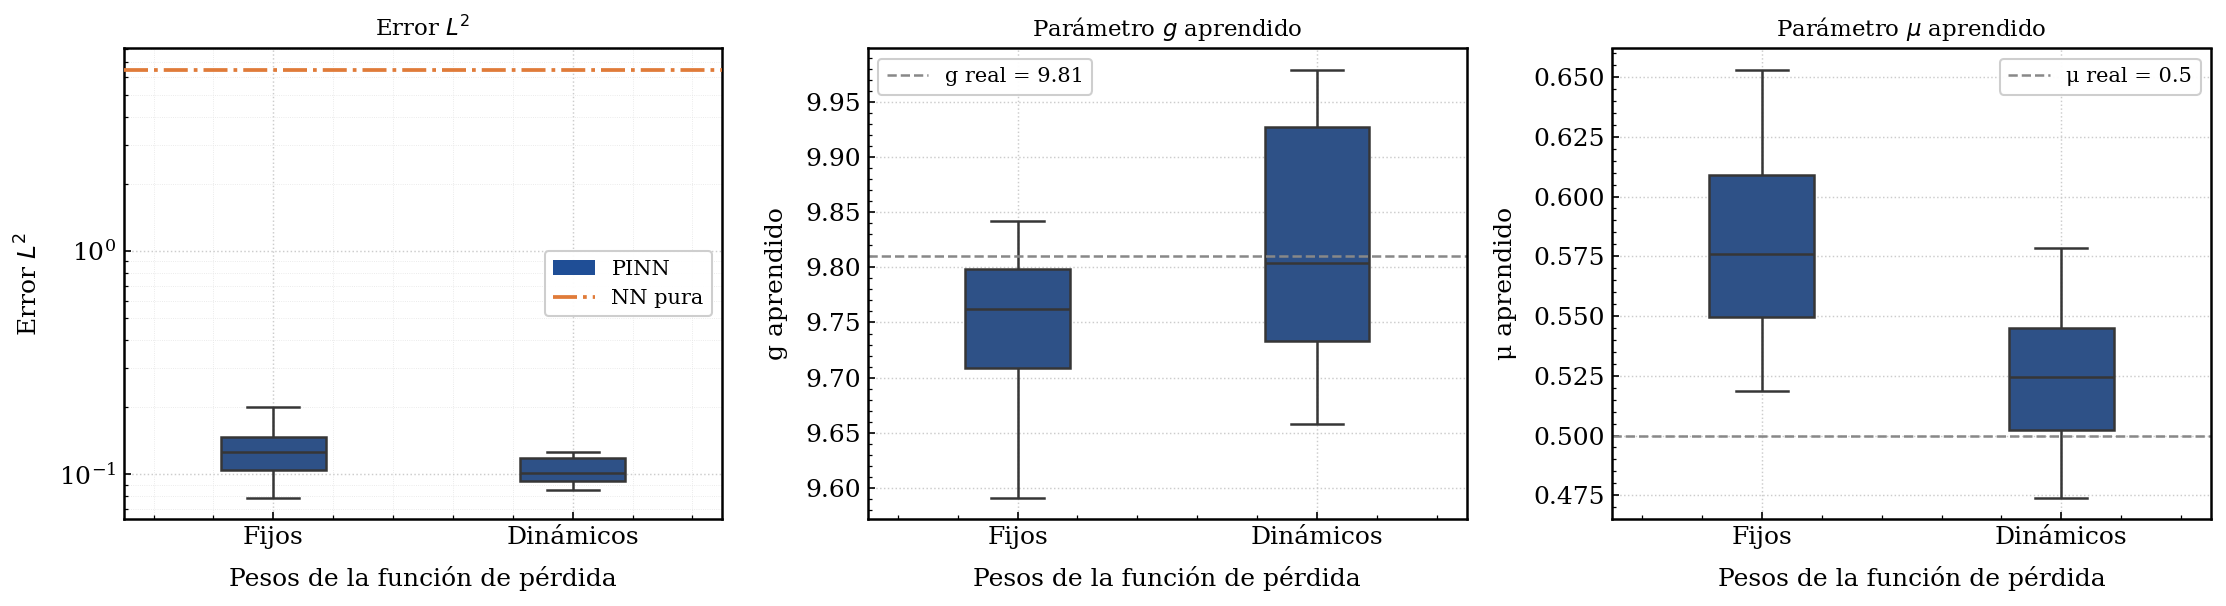

Fijos: L2=1.3603e-01 ± 5.3664e-02 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
Dinámicos: L2=1.0973e-01 ± 2.7159e-02 | g=9.8178 ± 0.1191 | mu=0.5262 ± 0.0323
NN pura: 6.4777e+00 ± 1.5902e+01


In [8]:
mask_eje5_pendulo = (
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje5_pendulo = df_pendulo[mask_eje5_pendulo].copy()
df_eje5_pendulo["use_dynamic_weights"] = df_eje5_pendulo["use_dynamic_weights"].astype(str).map(
    {"False": "Fijos", "True": "Dinámicos"}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df_eje5_pendulo, x="use_dynamic_weights", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(df_base_pendulo["error_l2_nn"].mean(), color=C_NN,
           linewidth=1.8, linestyle="-.", label="NN pura", zorder=3)
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
sns.boxplot(
    data=df_eje5_pendulo, x="use_dynamic_weights", y="g_learned",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
sns.boxplot(
    data=df_eje5_pendulo, x="use_dynamic_weights", y="mu_learned",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for dw, grp in df_pendulo[mask_eje5_pendulo].groupby("use_dynamic_weights"):
    label = "Dinámicos" if dw else "Fijos"
    print(f"{label}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")
print(f"NN pura: {df_base_pendulo['error_l2_nn'].mean():.4e} ± {df_base_pendulo['error_l2_nn'].std():.4e}")

## Eje 6 — Learning rate

Se comparan dos tasas de aprendizaje: 0.001 (BASE) y 0.01. El learning rate
afecta tanto a la PINN como a la NN, por lo que se incluyen ambas en el
panel de error L2.

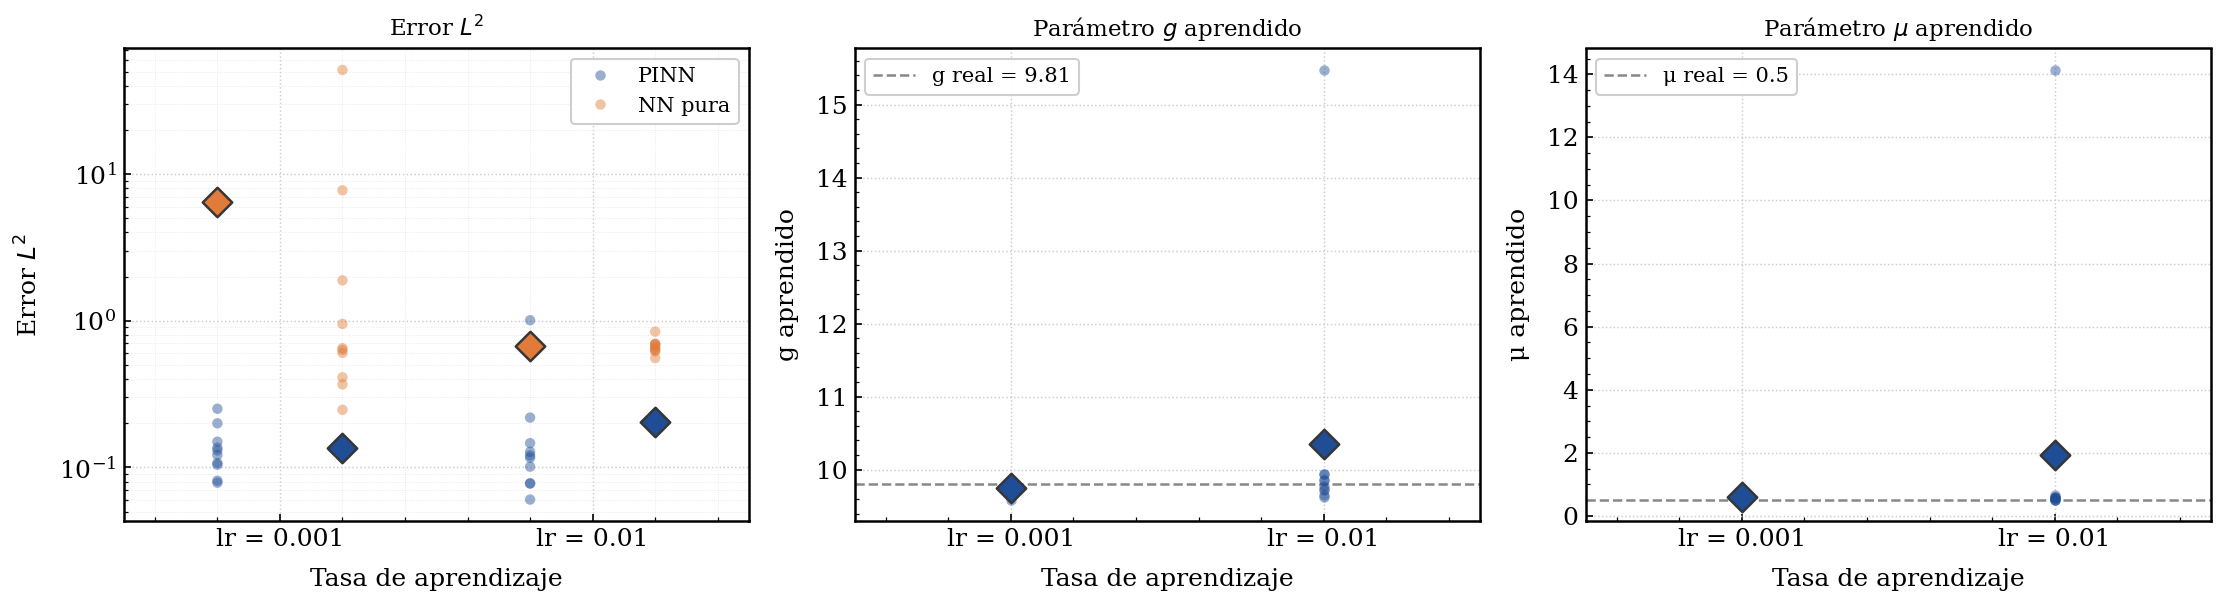

lr=0.001: L2=1.3603e-01 ± 5.3664e-02 | NN=6.4777e+00 ± 1.5902e+01 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
lr=0.01: L2=2.0549e-01 ± 2.8549e-01 | NN=6.6920e-01 ± 7.4992e-02 | g=10.3571 ± 1.8008 | mu=1.9269 ± 4.2908


In [9]:
mask_eje6_pendulo = (
    df_pendulo["lr"].isin([0.001, 0.01]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"])
)

df_eje6_pendulo = df_pendulo[mask_eje6_pendulo].copy()
df_eje6_pendulo["lr"] = df_eje6_pendulo["lr"].astype(str)

df_eje6_long = df_eje6_pendulo.melt(
    id_vars=["lr"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})
df_eje6_long["lr_label"] = df_eje6_long["lr"].map(
    {"0.001": "lr = 0.001", "0.01": "lr = 0.01"}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje6_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=False, ax=ax
)
means_l2 = df_eje6_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_l2, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=False,
    linewidth=1.2, ax=ax, legend=False
)
handles, labels = ax.get_legend_handles_labels()
seen = set(); h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label); h.append(handle); l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
df_eje6_pendulo["lr_label"] = df_eje6_pendulo["lr"].map(
    {"0.001": "lr = 0.001", "0.01": "lr = 0.01"}
)
sns.stripplot(
    data=df_eje6_pendulo, x="lr_label", y="g_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_g = df_eje6_pendulo.groupby("lr_label")["g_learned"].mean().reset_index()
sns.stripplot(
    data=means_g, x="lr_label", y="g_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
sns.stripplot(
    data=df_eje6_pendulo, x="lr_label", y="mu_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_mu = df_eje6_pendulo.groupby("lr_label")["mu_learned"].mean().reset_index()
sns.stripplot(
    data=means_mu, x="lr_label", y="mu_learned",
    color=C_PINN, order=["lr = 0.001", "lr = 0.01"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df_pendulo[mask_eje6_pendulo].groupby("lr"):
    print(f"lr={lr_val}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")

## Eje 7 — Nivel de ruido

Este eje es exclusivo del péndulo amortiguado. Se estudia cómo afecta el
nivel de ruido en los datos de entrenamiento (0.0, 0.05, 0.1, 0.2) a la
capacidad de la PINN para recuperar g y μ, y cómo se compara con la NN
pura que solo ajusta los datos ruidosos sin conocer la física.

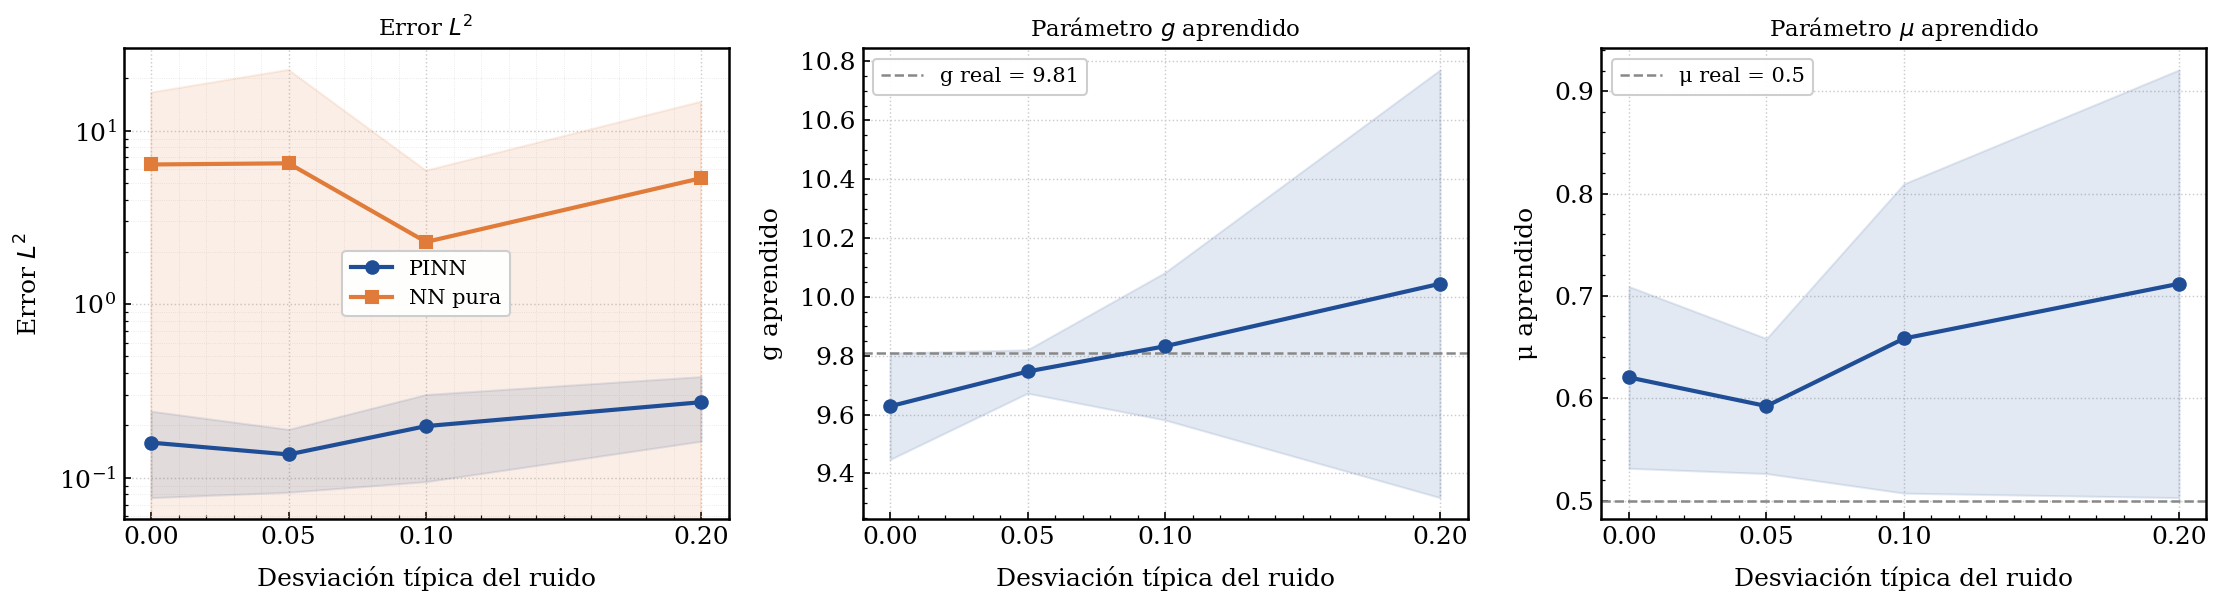

 ruido      PINN L2        NN L2    g media    g std   mu media   mu std
  0.00   1.5913e-01   6.3787e+00     9.6280   0.1808     0.6204   0.0888
  0.05   1.3603e-01   6.4777e+00     9.7462   0.0738     0.5924   0.0659
  0.10   1.9816e-01   2.2823e+00     9.8320   0.2506     0.6584   0.1511
  0.20   2.7211e-01   5.3190e+00    10.0444   0.7268     0.7119   0.2089


In [10]:
mask_eje7_pendulo = (
    df_pendulo["noise_std"].isin([0.0, 0.05, 0.1, 0.2]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["train_region"]       == BASE_PENDULO["train_region"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje7_pendulo = df_pendulo[mask_eje7_pendulo].groupby("noise_std").agg(
    pinn_mean  =("error_l2_pinn", "mean"),
    pinn_std   =("error_l2_pinn", "std"),
    nn_mean    =("error_l2_nn",   "mean"),
    nn_std     =("error_l2_nn",   "std"),
    g_mean     =("g_learned",     "mean"),
    g_std      =("g_learned",     "std"),
    mu_mean    =("mu_learned",    "mean"),
    mu_std     =("mu_learned",    "std"),
).reset_index()

x = df_eje7_pendulo["noise_std"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje7_pendulo["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje7_pendulo["pinn_mean"] - df_eje7_pendulo["pinn_std"],
    df_eje7_pendulo["pinn_mean"] + df_eje7_pendulo["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje7_pendulo["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje7_pendulo["nn_mean"] - df_eje7_pendulo["nn_std"],
    df_eje7_pendulo["nn_mean"] + df_eje7_pendulo["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.set_xlabel("Desviación típica del ruido", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje7_pendulo["g_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje7_pendulo["g_mean"] - df_eje7_pendulo["g_std"],
    df_eje7_pendulo["g_mean"] + df_eje7_pendulo["g_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.set_xlabel("Desviación típica del ruido", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
ax.plot(x, df_eje7_pendulo["mu_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje7_pendulo["mu_mean"] - df_eje7_pendulo["mu_std"],
    df_eje7_pendulo["mu_mean"] + df_eje7_pendulo["mu_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.set_xlabel("Desviación típica del ruido", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_xticks(x)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_noise.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'ruido':>6} {'PINN L2':>12} {'NN L2':>12} {'g media':>10} "
      f"{'g std':>8} {'mu media':>10} {'mu std':>8}")
for _, row in df_eje7_pendulo.iterrows():
    print(f"{row['noise_std']:>6.2f} {row['pinn_mean']:>12.4e} {row['nn_mean']:>12.4e} "
          f"{row['g_mean']:>10.4f} {row['g_std']:>8.4f} "
          f"{row['mu_mean']:>10.4f} {row['mu_std']:>8.4f}")

## Ejes 8 y 10 — Puntos de entrenamiento × región

Se estudia el efecto del número de puntos de entrenamiento (5, 10, 15, 30)
para dos regiones distintas: 50% (BASE) y 70% del dominio temporal. Tanto
la PINN como la NN se benefician de más datos, por lo que se incluyen ambas
en el panel de error L2. Para g y μ solo tiene sentido mostrar la PINN.

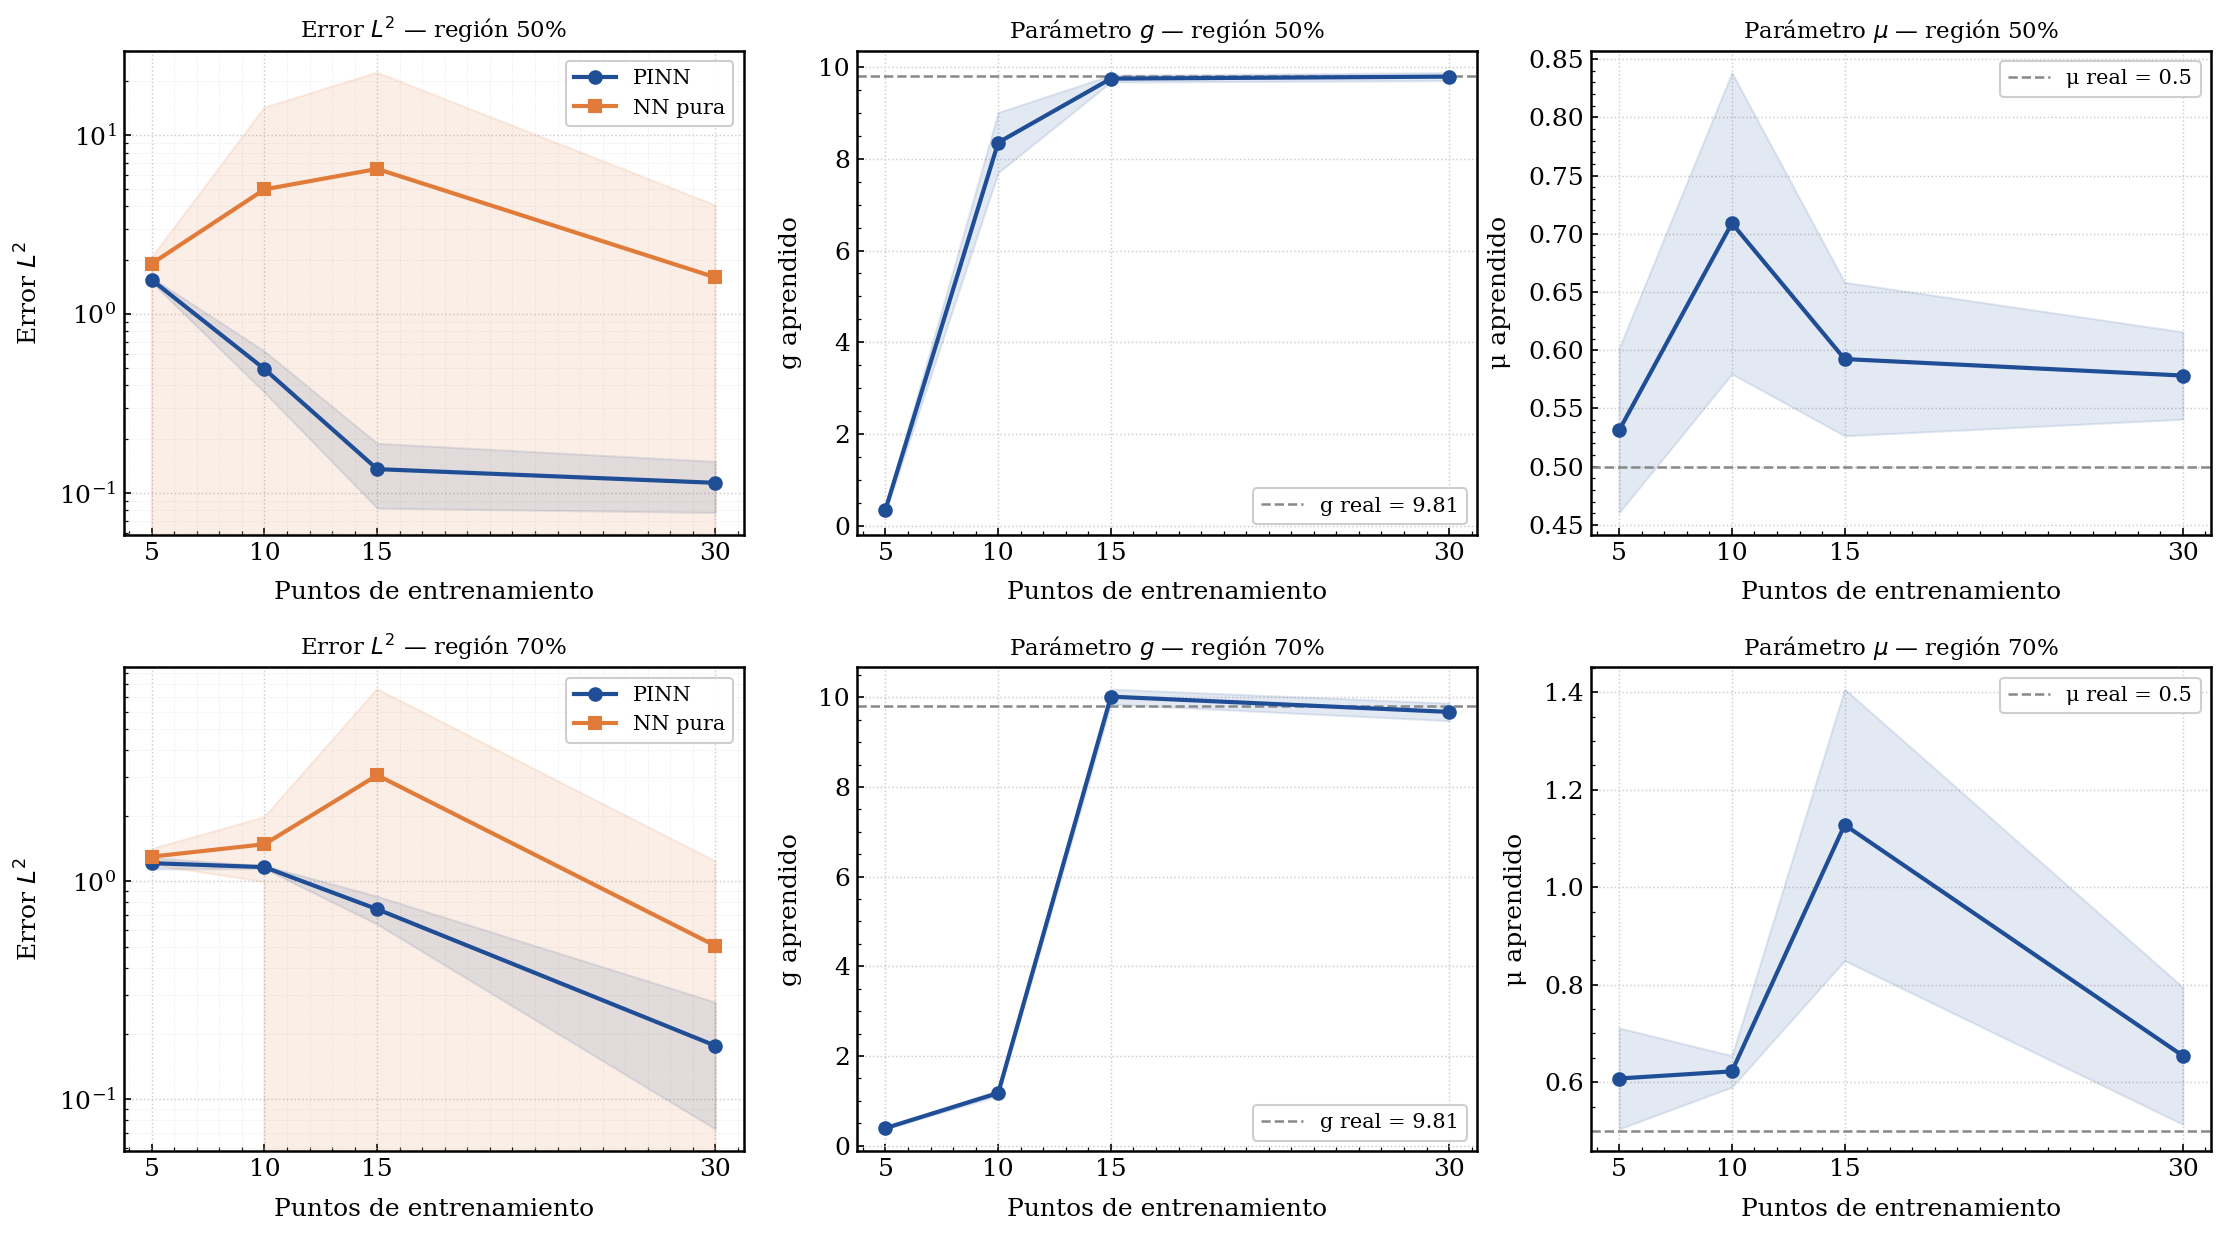


Región 50%:
  5 pts: L2=1.5532e+00 ± 4.6656e-02 | g=0.3548 ± 0.0647 | mu=0.5313 ± 0.0707
  10 pts: L2=4.9320e-01 ± 1.2793e-01 | g=8.3533 ± 0.6552 | mu=0.7090 ± 0.1293
  15 pts: L2=1.3603e-01 ± 5.3664e-02 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
  30 pts: L2=1.1402e-01 ± 3.6229e-02 | g=9.7901 ± 0.0877 | mu=0.5783 ± 0.0375

Región 70%:
  5 pts: L2=1.2107e+00 ± 7.1672e-02 | g=0.3908 ± 0.0202 | mu=0.6075 ± 0.1037
  10 pts: L2=1.1610e+00 ± 1.9142e-02 | g=1.1745 ± 0.0611 | mu=0.6222 ± 0.0322
  15 pts: L2=7.4439e-01 ± 1.0892e-01 | g=10.0152 ± 0.1682 | mu=1.1278 ± 0.2785
  30 pts: L2=1.7602e-01 ± 1.0298e-01 | g=9.6747 ± 0.1967 | mu=0.6541 ± 0.1407


In [11]:
mask_eje8_pendulo = (
    (df_pendulo["train_region"]       == 0.5) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

mask_eje10_pendulo = (
    (df_pendulo["train_region"]       == 0.7) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje8_pendulo = df_pendulo[mask_eje8_pendulo].groupby("num_train_points").agg(
    pinn_mean=("error_l2_pinn", "mean"), pinn_std=("error_l2_pinn", "std"),
    nn_mean=  ("error_l2_nn",   "mean"), nn_std=  ("error_l2_nn",   "std"),
    g_mean=   ("g_learned",     "mean"), g_std=   ("g_learned",     "std"),
    mu_mean=  ("mu_learned",    "mean"), mu_std=  ("mu_learned",    "std"),
).reset_index()

df_eje10_pendulo = df_pendulo[mask_eje10_pendulo].groupby("num_train_points").agg(
    pinn_mean=("error_l2_pinn", "mean"), pinn_std=("error_l2_pinn", "std"),
    nn_mean=  ("error_l2_nn",   "mean"), nn_std=  ("error_l2_nn",   "std"),
    g_mean=   ("g_learned",     "mean"), g_std=   ("g_learned",     "std"),
    mu_mean=  ("mu_learned",    "mean"), mu_std=  ("mu_learned",    "std"),
).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 8.4))

for row_idx, (df_e, region) in enumerate([(df_eje8_pendulo, "50%"), (df_eje10_pendulo, "70%")]):
    x = df_e["num_train_points"].values

    # Panel izquierdo: error L2
    ax = axes[row_idx, 0]
    ax.plot(x, df_e["pinn_mean"], "o-", color=C_PINN, linewidth=2,
            markersize=6, label="PINN", zorder=3)
    ax.fill_between(x, df_e["pinn_mean"] - df_e["pinn_std"],
                       df_e["pinn_mean"] + df_e["pinn_std"],
                    color=C_PINN, alpha=0.12, zorder=2)
    ax.plot(x, df_e["nn_mean"], "s-", color=C_NN, linewidth=2,
            markersize=6, label="NN pura", zorder=3)
    ax.fill_between(x, df_e["nn_mean"] - df_e["nn_std"],
                       df_e["nn_mean"] + df_e["nn_std"],
                    color=C_NN, alpha=0.12, zorder=2)
    ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
    ax.set_ylabel("Error $L^2$", labelpad=8)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5")
    ax.set_title(f"Error $L^2$ — región {region}", fontsize=11)

    # Panel central: g aprendido
    ax = axes[row_idx, 1]
    ax.plot(x, df_e["g_mean"], "o-", color=C_PINN, linewidth=2,
            markersize=6, zorder=3)
    ax.fill_between(x, df_e["g_mean"] - df_e["g_std"],
                       df_e["g_mean"] + df_e["g_std"],
                    color=C_PINN, alpha=0.12, zorder=2)
    ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
               label=f"g real = {G_TRUE}", zorder=2)
    ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
    ax.set_ylabel("g aprendido", labelpad=8)
    ax.set_xticks(x)
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.set_title(f"Parámetro $g$ — región {region}", fontsize=11)

    # Panel derecho: mu aprendido
    ax = axes[row_idx, 2]
    ax.plot(x, df_e["mu_mean"], "o-", color=C_PINN, linewidth=2,
            markersize=6, zorder=3)
    ax.fill_between(x, df_e["mu_mean"] - df_e["mu_std"],
                       df_e["mu_mean"] + df_e["mu_std"],
                    color=C_PINN, alpha=0.12, zorder=2)
    ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
               label=f"μ real = {MU_TRUE}", zorder=2)
    ax.set_xlabel("Puntos de entrenamiento", labelpad=8)
    ax.set_ylabel("μ aprendido", labelpad=8)
    ax.set_xticks(x)
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.set_title(f"Parámetro $\\mu$ — región {region}", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje8_10_train_points.png", dpi=300, bbox_inches="tight")
plt.show()

for region, mask in [("50%", mask_eje8_pendulo), ("70%", mask_eje10_pendulo)]:
    print(f"\nRegión {region}:")
    for pts, grp in df_pendulo[mask].groupby("num_train_points"):
        print(f"  {pts} pts: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
              f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
              f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")

## Eje 9 — Región de entrenamiento

Se comparan tres regiones de entrenamiento: 30%, 50% (BASE) y 70% del dominio
temporal, manteniendo fijos los 15 puntos base. Una región mayor implica
observar más del comportamiento dinámico del péndulo, lo que debería facilitar
la recuperación de g y μ. Se incluye la NN en el panel de error L2.

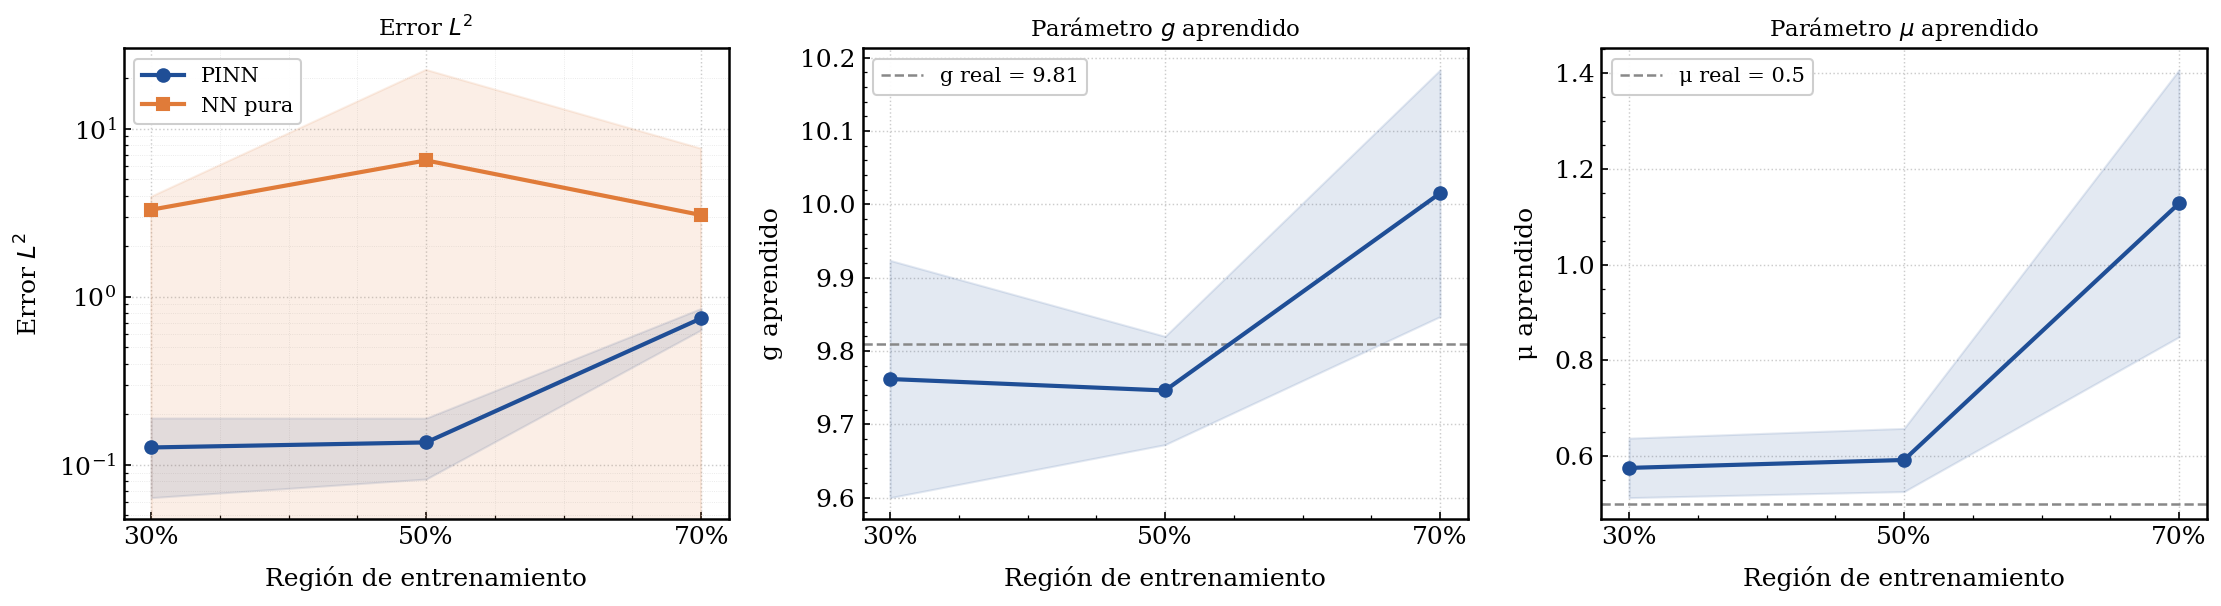

región=0.3: L2=1.2696e-01 ± 6.3120e-02 | NN=3.2960e+00 ± 6.3475e-01 | g=9.7619 ± 0.1617 | mu=0.5759 ± 0.0621
región=0.5: L2=1.3603e-01 ± 5.3664e-02 | NN=6.4777e+00 ± 1.5902e+01 | g=9.7462 ± 0.0738 | mu=0.5924 ± 0.0659
región=0.7: L2=7.4439e-01 ± 1.0892e-01 | NN=3.0645e+00 ± 4.5443e+00 | g=10.0152 ± 0.1682 | mu=1.1278 ± 0.2785


In [12]:
mask_eje9_pendulo = (
    df_pendulo["train_region"].isin([0.3, 0.5, 0.7]) &
    (df_pendulo["num_domain_points"]  == BASE_PENDULO["num_domain_points"]) &
    (df_pendulo["num_train_points"]   == BASE_PENDULO["num_train_points"]) &
    (df_pendulo["noise_std"]          == BASE_PENDULO["noise_std"]) &
    (df_pendulo["sampler"]            == BASE_PENDULO["sampler"]) &
    (df_pendulo["use_dynamic_weights"]== BASE_PENDULO["use_dynamic_weights"]) &
    (df_pendulo["optimizer"]          == BASE_PENDULO["optimizer"]) &
    (df_pendulo["hidden_layers"]      == BASE_PENDULO["hidden_layers"]) &
    (df_pendulo["lr"]                 == BASE_PENDULO["lr"])
)

df_eje9_pendulo = df_pendulo[mask_eje9_pendulo].groupby("train_region").agg(
    pinn_mean=("error_l2_pinn", "mean"), pinn_std=("error_l2_pinn", "std"),
    nn_mean=  ("error_l2_nn",   "mean"), nn_std=  ("error_l2_nn",   "std"),
    g_mean=   ("g_learned",     "mean"), g_std=   ("g_learned",     "std"),
    mu_mean=  ("mu_learned",    "mean"), mu_std=  ("mu_learned",    "std"),
).reset_index()

x      = df_eje9_pendulo["train_region"].values
xlabels = ["30%", "50%", "70%"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje9_pendulo["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, label="PINN", zorder=3)
ax.fill_between(x,
    df_eje9_pendulo["pinn_mean"] - df_eje9_pendulo["pinn_std"],
    df_eje9_pendulo["pinn_mean"] + df_eje9_pendulo["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje9_pendulo["nn_mean"], "s-", color=C_NN, linewidth=2,
        markersize=6, label="NN pura", zorder=3)
ax.fill_between(x,
    df_eje9_pendulo["nn_mean"] - df_eje9_pendulo["nn_std"],
    df_eje9_pendulo["nn_mean"] + df_eje9_pendulo["nn_std"],
    color=C_NN, alpha=0.12, zorder=2)
ax.set_xlabel("Región de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)
ax.set_title("Error $L^2$", fontsize=11)

# ── Panel central: g aprendido ────────────────────────────────────────────
ax = axes[1]
ax.plot(x, df_eje9_pendulo["g_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje9_pendulo["g_mean"] - df_eje9_pendulo["g_std"],
    df_eje9_pendulo["g_mean"] + df_eje9_pendulo["g_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(G_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"g real = {G_TRUE}", zorder=2)
ax.set_xlabel("Región de entrenamiento", labelpad=8)
ax.set_ylabel("g aprendido", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $g$ aprendido", fontsize=11)

# ── Panel derecho: mu aprendido ───────────────────────────────────────────
ax = axes[2]
ax.plot(x, df_eje9_pendulo["mu_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=6, zorder=3)
ax.fill_between(x,
    df_eje9_pendulo["mu_mean"] - df_eje9_pendulo["mu_std"],
    df_eje9_pendulo["mu_mean"] + df_eje9_pendulo["mu_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(MU_TRUE, color=C_RK4, linewidth=1.2, linestyle="--",
           label=f"μ real = {MU_TRUE}", zorder=2)
ax.set_xlabel("Región de entrenamiento", labelpad=8)
ax.set_ylabel("μ aprendido", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.set_title("Parámetro $\\mu$ aprendido", fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje9_train_region.png", dpi=300, bbox_inches="tight")
plt.show()

for region, grp in df_pendulo[mask_eje9_pendulo].groupby("train_region"):
    print(f"región={region:.1f}: L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e} "
          f"| g={grp['g_learned'].mean():.4f} ± {grp['g_learned'].std():.4f} "
          f"| mu={grp['mu_learned'].mean():.4f} ± {grp['mu_learned'].std():.4f}")

## Tabla resumen — todos los ejes

In [13]:
resumen_pendulo = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen_pendulo.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN L2 media": df_base_pendulo["error_l2_pinn"].mean(),
    "PINN L2 std":   df_base_pendulo["error_l2_pinn"].std(),
    "NN L2 media":   df_base_pendulo["error_l2_nn"].mean(),
    "NN L2 std":     df_base_pendulo["error_l2_nn"].std(),
    "g media":       df_base_pendulo["g_learned"].mean(),
    "g std":         df_base_pendulo["g_learned"].std(),
    "mu media":      df_base_pendulo["mu_learned"].mean(),
    "mu std":        df_base_pendulo["mu_learned"].std(),
    "N":             len(df_base_pendulo),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes_pendulo = [
    ("Eje 1 · Puntos colocación",  "num_domain_points", mask_eje1_pendulo),
    ("Eje 2 · Sampler",            "sampler",           mask_eje2_pendulo),
    ("Eje 3 · Optimizador",        "optimizer",         mask_eje3_pendulo),
    ("Eje 4 · Arquitectura",       "hidden_layers",     mask_eje4_pendulo),
    ("Eje 5 · Pesos dinámicos",    "use_dynamic_weights", mask_eje5_pendulo),
    ("Eje 6 · Learning rate",      "lr",                mask_eje6_pendulo),
    ("Eje 7 · Ruido",              "noise_std",         mask_eje7_pendulo),
    ("Eje 8 · Puntos train 50%",   "num_train_points",  mask_eje8_pendulo),
    ("Eje 9 · Región",             "train_region",      mask_eje9_pendulo),
    ("Eje 10 · Puntos train 70%",  "num_train_points",  mask_eje10_pendulo),
]

for eje_label, col, mask in ejes_pendulo:
    grp_all = df_pendulo[mask]
    for val, grp in grp_all.groupby(col):
        resumen_pendulo.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN L2 media": grp["error_l2_pinn"].mean(),
            "PINN L2 std":   grp["error_l2_pinn"].std(),
            "NN L2 media":   grp["error_l2_nn"].mean(),
            "NN L2 std":     grp["error_l2_nn"].std(),
            "g media":       grp["g_learned"].mean(),
            "g std":         grp["g_learned"].std(),
            "mu media":      grp["mu_learned"].mean(),
            "mu std":        grp["mu_learned"].std(),
            "N":             len(grp),
        })

# ── Formatear y mostrar ───────────────────────────────────────────────────
df_resumen_pendulo = pd.DataFrame(resumen_pendulo)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print(f"\n{'═'*140}")
print(f"{'EJE':<28} {'CONFIG':<22} {'PINN L2':>12} {'PINN std':>10} "
      f"{'NN L2':>12} {'NN std':>10} {'g media':>9} {'g std':>7} "
      f"{'mu media':>9} {'mu std':>7} {'N':>4}")
print(f"{'─'*140}")

eje_actual = None
for _, row in df_resumen_pendulo.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*140}")
        eje_actual = row["Eje"]
    print(f"{row['Eje']:<28} {row['Configuración']:<22} "
          f"{row['PINN L2 media']:>12.3e} {row['PINN L2 std']:>10.3e} "
          f"{row['NN L2 media']:>12.3e} {row['NN L2 std']:>10.3e} "
          f"{row['g media']:>9.4f} {row['g std']:>7.4f} "
          f"{row['mu media']:>9.4f} {row['mu std']:>7.4f} "
          f"{int(row['N']):>4}")

print(f"{'═'*140}")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                          CONFIG                      PINN L2   PINN std        NN L2     NN std   g media   g std  mu media  mu std    N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                         —                         1.360e-01  5.366e-02    6.478e+00  1.590e+01    9.7462  0.0738    0.5924  0.0659   10
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación    50                        6.199e-01  3.397e-01    6.478e+00  1.590e+01    7.9805  2.9372    2.5626  2.3952   10
Eje 1 · Puntos colocación    100                       5.446e-01  6.097e-01    6.478e+00  1.590e+01    9.9097  0.7166    1.0256  0.6374   10
Eje 1 · Punt